In [1]:
import pandas as pd
import numpy as np

from scipy.stats import norm

from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>.output_result { max-width:100% !important; }</style>"))

pd.set_option('display.max_columns', None)
np.set_printoptions(suppress=True)

In [2]:
def format_plot(ax, size_axes=6, size_title=8):
    font_title = {"size": size_title, "weight": 400, "name": "monospace"}

    font_axes = {"size": size_axes, "weight": "bold", "name": "monospace"}

    ax.grid(True, linestyle=":", alpha=0.6)
    sns.despine(ax=ax, left=True)

    if ax.get_legend():
        ax.legend(bbox_to_anchor=(1.1, 1))

    ax.set_title(f"\n\n{ax.get_title()}\n", fontdict=font_title)
    ax.set_xlabel(f"\n{ax.get_xlabel()} ➞", fontdict=font_axes)
    ax.set_ylabel(f"{ax.get_ylabel()} ➞\n", fontdict=font_axes)

# performances
def print_performances(y_true, y_hat):
    
    ##### confusion matrix
    _, ax = plt.subplots(1,2,figsize=(8, 4))
    ax1, ax2 = ax[0], ax[1]
    
    # abs counts
    conf_matrix = pd.crosstab(index=y_true, columns=y_hat)
    
    sns.heatmap(data=conf_matrix,
                cmap="rocket",
                annot=True,
                cbar=False,
                fmt=".0f", 
                ax=ax1)
    
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    ax1.set_title('Confusion matrix (absolute)')
    
    # normalized by actual class
    conf_matrix_norm = pd.crosstab(index=y_true, columns=y_hat, normalize='index')
    sns.heatmap(data=conf_matrix_norm, cmap="rocket", annot=True, cbar=False, fmt=".2f", ax=ax2)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    ax2.set_title('Confusion matrix (normalized by class)')
    
    format_plot(ax1)
    format_plot(ax2)
    plt.show()
    
    # performances
    print(f'Accuracy: {round(accuracy_score(y_true, y_hat), 3)}')
    print(f'Recall: {round(recall_score(y_true, y_hat), 3)}')
    print(f'Precision: {round(precision_score(y_true, y_hat), 3)}')
    print(f'F1: {round(f1_score(y_true, y_hat), 3)}')
    print(f'ROC AUC: {round(roc_auc_score(y_true, y_hat), 3)}')

# Naive Bayes

In [3]:
def fitNB(data, class_att, alpha=1):
    model = {}
    
    # Računanje apriori verovatnoća
    apriori = data[class_att].value_counts()
    apriori = apriori/apriori.sum(axis=0)
    model['_apriori'] = apriori
    
    for attribute in data.drop(class_att, axis=1).columns:
        if data[attribute].dtype == 'object':  # za kategoričke
            # Kreiranje matrica kontigencije i dodavanje additive smoothing:
            mat_cont = pd.crosstab(data[attribute], data[class_att]) + alpha
            mat_cont = mat_cont / mat_cont.sum(axis=0)
            model[attribute] = mat_cont 
        else: # za numeričke
            # Računanje mean i std za svaku klasu
            class_mean_std = data.groupby(class_att)[attribute].agg(['mean', 'std'])
            model[attribute] = class_mean_std.T
            
    return model

def predictNB(model, new_instance):
    class_log_prob = {}
    class_prob = {}
    class_probabilities = {}
    
    # Računanje verovatnoća po svakoj klasi za nove instance
    for class_value in model['_apriori'].index:
        log_prob = 0
        
        # Računanje verovatnoća po svakom atributu za datu klasu
        for attribute in model.keys():
                        
            if attribute != '_apriori':
                # za nedostajuće vrednosti
                if new_instance[attribute] is np.nan:
                    continue
                
                if isinstance(new_instance[attribute], str): # za kategoričke
                    if new_instance[attribute] not in model[attribute].index:
                        continue
                    log_prob += np.log(model[attribute][class_value].loc[new_instance[attribute]])
                else: # za numeričke
                    mean, std = model[attribute][class_value].loc['mean'], model[attribute][class_value].loc['std']
                    log_prob += np.log(norm.pdf(x=new_instance[attribute], loc=mean, scale=std))
            else:
                log_prob += np.log(model['_apriori'][class_value])
        
        class_log_prob[class_value] = log_prob
        
    
    for class_value in class_log_prob.keys():
        class_prob[class_value] = np.exp(class_log_prob[class_value]-(max((class_log_prob.values()))))
    for class_value in class_prob.keys():
        class_probabilities[class_value] = class_prob[class_value]/(sum(class_prob.values()))
    
        
    # Predvidjanje:
    prediction = max(class_probabilities, key=class_probabilities.get)
    
    return prediction, class_probabilities

# Fair Naive Bayes

In [4]:
def fit(data, class_att, positive_class, sensitive_att, p, alpha=1):
    model = {}
    
    # Računanje apriori verovatnoća
    apriori = data[class_att].value_counts()
    apriori = apriori/apriori.sum(axis=0)
    model['_apriori'] = apriori
    
    for attribute in data.drop(class_att, axis=1).columns:
        if attribute in sensitive_att: #za osetljivi atribut
            a = min(pd.crosstab(data[attribute], data[class_att])[positive_class])
            b = max(pd.crosstab(data[attribute], data[class_att])[positive_class])
            c = a/b
            if p < c:
                print(f'Atribut {attribute} je već više balansiran od traženih {p}, zadržaće se postojeći balans koji iznosi {c}')
                continue
            elif p > 0.99:
                print('Nije moguće toliko izbalansirati')
                break
            else:
                alpha_s = (p*b-a)/(1-p)
                mat_cont = pd.crosstab(data[attribute], data[class_att]) + alpha_s
                mat_cont = mat_cont / mat_cont.sum(axis=0)
                model[attribute] = mat_cont
            
        else:
            
            if data[attribute].dtype == 'object':  # za kategoričke
                # Kreiranje matrica kontigencije i dodavanje additive smoothing:
                mat_cont = pd.crosstab(data[attribute], data[class_att]) + alpha
                mat_cont = mat_cont / mat_cont.sum(axis=0)
                model[attribute] = mat_cont
            else: # za numeričke
                # Računanje mean i std za svaku klasu
                class_mean_std = data.groupby(class_att)[attribute].agg(['mean', 'std'])
                model[attribute] = class_mean_std.T
            
    return model

In [5]:
def predict(model, new_instance, target_class=1, other_class=0, threshold=0.5):
    class_log_prob = {}
    class_prob = {}
    class_probabilities = {}
    
    # Računanje verovatnoća po svakoj klasi za nove instance
    for class_value in model['_apriori'].index:
        log_prob = 0
        
        # Računanje verovatnoća po svakom atributu za datu klasu
        for attribute in model.keys():
                        
            if attribute != '_apriori':
                # za nedostajuće vrednosti
                if new_instance[attribute] is np.nan:
                    continue
                
                if isinstance(new_instance[attribute], str): # za kategoričke
                    if new_instance[attribute] not in model[attribute].index:
                        continue
                    log_prob += np.log(model[attribute][class_value].loc[new_instance[attribute]])
                else: # za numeričke
                    mean, std = model[attribute][class_value].loc['mean'], model[attribute][class_value].loc['std']
                    log_prob += np.log(norm.pdf(x=new_instance[attribute], loc=mean, scale=std))
            else:
                log_prob += np.log(model['_apriori'][class_value])
        
        class_log_prob[class_value] = log_prob
        
    
    for class_value in class_log_prob.keys():
        class_prob[class_value] = np.exp(class_log_prob[class_value]-(max((class_log_prob.values()))))
    for class_value in class_prob.keys():
        class_probabilities[class_value] = class_prob[class_value]/(sum(class_prob.values()))
    
        
    # Predvidjanje:
    if class_probabilities[target_class] >= threshold:
        prediction = target_class
    else: 
        prediction = other_class
    
    return prediction, class_probabilities

In [6]:
#Mere za diskriminaciju

def di (X_test_p, prediction, sens_att, priv_class, disc_class):
    PPD = (X_test_p[prediction][(X_test_p[sens_att]==disc_class) & (X_test_p[prediction]==True)].count()) 
    D = (X_test_p[prediction][(X_test_p[sens_att] == disc_class)]).count()
    PPP = (X_test_p[prediction][(X_test_p[sens_att] == priv_class) & (X_test_p[prediction]==True)].count())
    P = (X_test_p[prediction][(X_test_p[sens_att] == priv_class)]).count()
    DI = round((PPD/D)/(PPP/P), 3)
    return DI

def eq (X_test, X_test_p, actual, prediction, sens_att, priv_class, disc_class):
    TPD = (X_test_p[prediction][(X_test_p[sens_att] == disc_class) & (X_test_p[prediction]==True) & (X_test[actual]==True)].count()) 
    APD = (X_test[actual][(X_test[sens_att] == disc_class) & (X_test[actual]==True)].count())
    TPP = (X_test_p[prediction][(X_test_p[sens_att] == priv_class) & (X_test_p[prediction]==True) & (X_test[actual]==True)].count()) 
    APP = (X_test[actual][(X_test[sens_att] == priv_class) & (X_test[actual]==True)].count()) 
    EQ = round((TPD/APD)/(TPP/APP), 3)
    return EQ

# Adult dataset

#### Priprema podataka

In [7]:
data = pd.read_csv('data/adult.csv') 
data['income'] = np.where(data['income'] == '>50K', 1, 0)
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0


In [8]:
data[data == '?'] = np.nan 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        46043 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       46033 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   47985 non-null  object
 14  income           48842 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 5.6+ MB


In [9]:
data = data.drop('fnlwgt', axis=1)

In [10]:
mat_cont = pd.crosstab(data['gender'], data['income'])
mat_cont

income,0,1
gender,,
Female,14423,1769
Male,22732,9918


In [11]:
mat_cont2 = pd.crosstab(data['race'], data['income'])
mat_cont2

income,0,1
race,,
Amer-Indian-Eskimo,415,55
Asian-Pac-Islander,1110,409
Black,4119,566
Other,356,50
White,31155,10607


In [12]:
data

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


### Primena osnovnog algoritma Naive Bayes

*************************************** Women ************************************ 


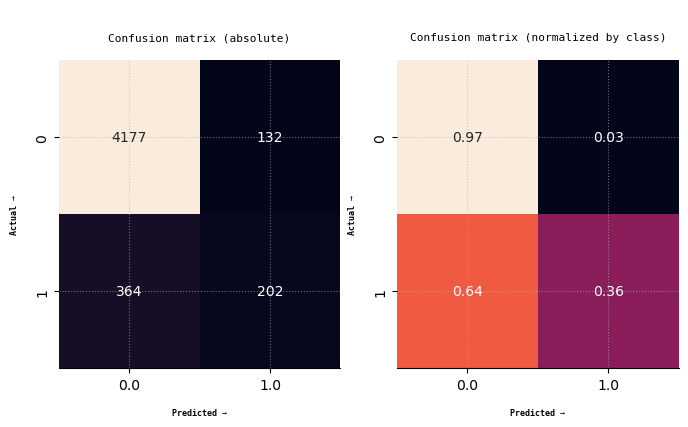

Accuracy: 0.898
Recall: 0.357
Precision: 0.605
F1: 0.449
ROC AUC: 0.663
**************************************** Men ************************************* 


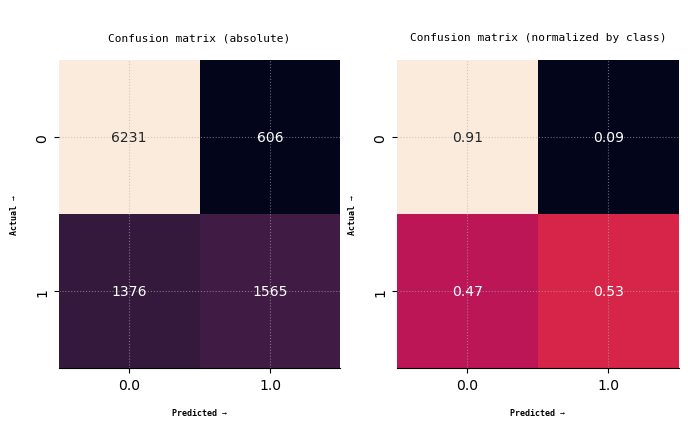

Accuracy: 0.797
Recall: 0.532
Precision: 0.721
F1: 0.612
ROC AUC: 0.722
**************************************** All ************************************* 


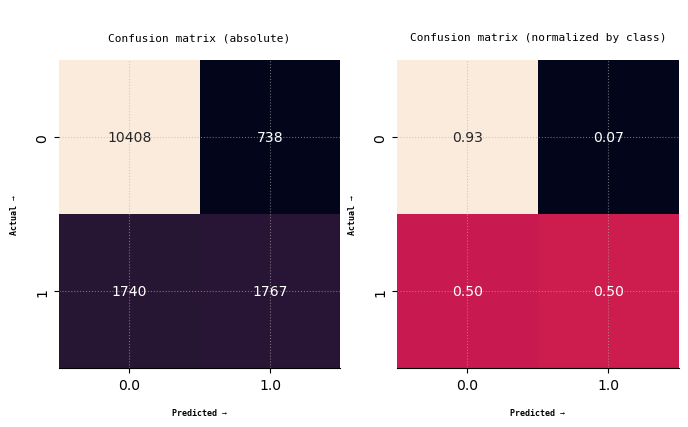

Accuracy: 0.831
Recall: 0.504
Precision: 0.705
F1: 0.588
ROC AUC: 0.719
Disparate impact: 0.309
Equal opportunity: 0.671


In [13]:
X_trainO, X_testO = train_test_split(data, test_size=0.3, random_state=297)
X_trainO, X_testO = X_trainO.reset_index(drop=True), X_testO.reset_index(drop=True)

X_test_pO = X_testO.drop('income', axis=1)

modelO = fitNB(data=X_trainO, class_att='income', alpha=0)


for i in range(len(X_test_pO)):
    predictionO, confidenceO = predictNB(modelO, X_test_pO.loc[i])
    
    X_test_pO.loc[i,'prediction'] = predictionO
    
    for klasa in confidenceO:
        X_test_pO.loc[i,'class='+str(klasa)] = confidenceO[klasa]

# Women
print('*************************************** Women ************************************ ')
print_performances(y_true=X_testO.loc[X_testO['gender'] == 'Female', 'income'].reset_index(drop=True),
                   y_hat=X_test_pO.loc[X_test_pO['gender'] == 'Female', 'prediction'].reset_index(drop=True))

# Men
print('**************************************** Men ************************************* ')
print_performances(y_true=X_testO.loc[X_testO['gender'] == 'Male', 'income'].reset_index(drop=True),
                   y_hat=X_test_pO.loc[X_test_pO['gender'] == 'Male', 'prediction'].reset_index(drop=True))

# All
print('**************************************** All ************************************* ')
print_performances(y_true=X_testO['income'], y_hat=X_test_pO['prediction'])


#Disparate impact:
PPFO = (X_test_pO['prediction'][(X_test_pO['gender'] == 'Female') & (X_test_pO['prediction']==True)].count())
FO = (X_test_pO['prediction'][(X_test_pO['gender'] == 'Female')]).count()
PPMO = (X_test_pO['prediction'][(X_test_pO['gender'] == 'Male') & (X_test_pO['prediction']==True)].count())
MO = (X_test_pO['prediction'][(X_test_pO['gender'] == 'Male')]).count()
DIO = round((PPFO/FO)/(PPMO/MO), 3)

#Equal opportunity:
TPFO = (X_test_pO['prediction'][(X_test_pO['gender'] == 'Female') & (X_test_pO['prediction']==True) & (X_testO['income']==True)].count())
APFO = (X_testO['income'][(X_testO['gender'] == 'Female') & (X_testO['income']==True)].count())
TPMO = (X_test_pO['prediction'][(X_test_pO['gender'] == 'Male') & (X_test_pO['prediction']==True) & (X_testO['income']==True)].count())
APMO = (X_testO['income'][(X_testO['gender'] == 'Male') & (X_testO['income']==True)].count())
EQO = round((TPFO/APFO)/(TPMO/APMO), 3)

print(f'Disparate impact: {DIO}')
print (f'Equal opportunity: {EQO}')

### Primena modifikovane verzije algoritma Naive Bayes

#### Za p=0.8

In [14]:
X_train1, X_test1 = train_test_split(data, test_size=0.3, random_state=297)
X_train1, X_test1 = X_train1.reset_index(drop=True), X_test1.reset_index(drop=True)

X_test_p1 = X_test1.drop('income', axis=1)

In [15]:
model1 = fit(data=X_train1, class_att='income', positive_class = 1, alpha=10, sensitive_att=['gender', 'relationship', 'race'], p=0.8)

In [16]:
model1

{'_apriori': 0    0.760742
 1    0.239258
 Name: income, dtype: float64,
 'age': income          0          1
 mean    36.891345  44.272372
 std     14.132281  10.550232,
 'workclass': income                   0         1
 workclass                           
 Federal-gov       0.025287  0.049542
 Local-gov         0.064307  0.083230
 Never-worked      0.000699  0.001239
 Private           0.762880  0.638098
 Self-emp-inc      0.021915  0.082859
 Self-emp-not-inc  0.081617  0.095244
 State-gov         0.042391  0.048303
 Without-pay       0.000905  0.001486,
 'education': income               0         1
 education                       
 10th          0.035882  0.008153
 11th          0.047996  0.008993
 12th          0.017119  0.004317
 1st-4th       0.007146  0.001679
 5th-6th       0.012801  0.003477
 7th-8th       0.024495  0.006835
 9th           0.018839  0.004916
 Assoc-acdm    0.032099  0.035252
 Assoc-voc     0.041499  0.045444
 Bachelors     0.124881  0.284652
 Doctorate    

In [17]:
time_started = datetime.now()

for i in range(len(X_test_p1)):
    print(f'Iteration: {i}')
    prediction1, confidence1 = predict(model=model1, new_instance=X_test_p1.loc[i])
    
    X_test_p1.loc[i,'prediction'] = prediction1
    
    for klasa in confidence1:
        X_test_p1.loc[i,'class='+str(klasa)] = confidence1[klasa]
        
time_finished = datetime.now()
run_last = (time_finished - time_started).seconds / 60
print(f'-----------------------------\nPrediction last: {run_last} mins.')

Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
It

Iteration: 729
Iteration: 730
Iteration: 731
Iteration: 732
Iteration: 733
Iteration: 734
Iteration: 735
Iteration: 736
Iteration: 737
Iteration: 738
Iteration: 739
Iteration: 740
Iteration: 741
Iteration: 742
Iteration: 743
Iteration: 744
Iteration: 745
Iteration: 746
Iteration: 747
Iteration: 748
Iteration: 749
Iteration: 750
Iteration: 751
Iteration: 752
Iteration: 753
Iteration: 754
Iteration: 755
Iteration: 756
Iteration: 757
Iteration: 758
Iteration: 759
Iteration: 760
Iteration: 761
Iteration: 762
Iteration: 763
Iteration: 764
Iteration: 765
Iteration: 766
Iteration: 767
Iteration: 768
Iteration: 769
Iteration: 770
Iteration: 771
Iteration: 772
Iteration: 773
Iteration: 774
Iteration: 775
Iteration: 776
Iteration: 777
Iteration: 778
Iteration: 779
Iteration: 780
Iteration: 781
Iteration: 782
Iteration: 783
Iteration: 784
Iteration: 785
Iteration: 786
Iteration: 787
Iteration: 788
Iteration: 789
Iteration: 790
Iteration: 791
Iteration: 792
Iteration: 793
Iteration: 794
Iteration:

Iteration: 1334
Iteration: 1335
Iteration: 1336
Iteration: 1337
Iteration: 1338
Iteration: 1339
Iteration: 1340
Iteration: 1341
Iteration: 1342
Iteration: 1343
Iteration: 1344
Iteration: 1345
Iteration: 1346
Iteration: 1347
Iteration: 1348
Iteration: 1349
Iteration: 1350
Iteration: 1351
Iteration: 1352
Iteration: 1353
Iteration: 1354
Iteration: 1355
Iteration: 1356
Iteration: 1357
Iteration: 1358
Iteration: 1359
Iteration: 1360
Iteration: 1361
Iteration: 1362
Iteration: 1363
Iteration: 1364
Iteration: 1365
Iteration: 1366
Iteration: 1367
Iteration: 1368
Iteration: 1369
Iteration: 1370
Iteration: 1371
Iteration: 1372
Iteration: 1373
Iteration: 1374
Iteration: 1375
Iteration: 1376
Iteration: 1377
Iteration: 1378
Iteration: 1379
Iteration: 1380
Iteration: 1381
Iteration: 1382
Iteration: 1383
Iteration: 1384
Iteration: 1385
Iteration: 1386
Iteration: 1387
Iteration: 1388
Iteration: 1389
Iteration: 1390
Iteration: 1391
Iteration: 1392
Iteration: 1393
Iteration: 1394
Iteration: 1395
Iteratio

Iteration: 1864
Iteration: 1865
Iteration: 1866
Iteration: 1867
Iteration: 1868
Iteration: 1869
Iteration: 1870
Iteration: 1871
Iteration: 1872
Iteration: 1873
Iteration: 1874
Iteration: 1875
Iteration: 1876
Iteration: 1877
Iteration: 1878
Iteration: 1879
Iteration: 1880
Iteration: 1881
Iteration: 1882
Iteration: 1883
Iteration: 1884
Iteration: 1885
Iteration: 1886
Iteration: 1887
Iteration: 1888
Iteration: 1889
Iteration: 1890
Iteration: 1891
Iteration: 1892
Iteration: 1893
Iteration: 1894
Iteration: 1895
Iteration: 1896
Iteration: 1897
Iteration: 1898
Iteration: 1899
Iteration: 1900
Iteration: 1901
Iteration: 1902
Iteration: 1903
Iteration: 1904
Iteration: 1905
Iteration: 1906
Iteration: 1907
Iteration: 1908
Iteration: 1909
Iteration: 1910
Iteration: 1911
Iteration: 1912
Iteration: 1913
Iteration: 1914
Iteration: 1915
Iteration: 1916
Iteration: 1917
Iteration: 1918
Iteration: 1919
Iteration: 1920
Iteration: 1921
Iteration: 1922
Iteration: 1923
Iteration: 1924
Iteration: 1925
Iteratio

Iteration: 2406
Iteration: 2407
Iteration: 2408
Iteration: 2409
Iteration: 2410
Iteration: 2411
Iteration: 2412
Iteration: 2413
Iteration: 2414
Iteration: 2415
Iteration: 2416
Iteration: 2417
Iteration: 2418
Iteration: 2419
Iteration: 2420
Iteration: 2421
Iteration: 2422
Iteration: 2423
Iteration: 2424
Iteration: 2425
Iteration: 2426
Iteration: 2427
Iteration: 2428
Iteration: 2429
Iteration: 2430
Iteration: 2431
Iteration: 2432
Iteration: 2433
Iteration: 2434
Iteration: 2435
Iteration: 2436
Iteration: 2437
Iteration: 2438
Iteration: 2439
Iteration: 2440
Iteration: 2441
Iteration: 2442
Iteration: 2443
Iteration: 2444
Iteration: 2445
Iteration: 2446
Iteration: 2447
Iteration: 2448
Iteration: 2449
Iteration: 2450
Iteration: 2451
Iteration: 2452
Iteration: 2453
Iteration: 2454
Iteration: 2455
Iteration: 2456
Iteration: 2457
Iteration: 2458
Iteration: 2459
Iteration: 2460
Iteration: 2461
Iteration: 2462
Iteration: 2463
Iteration: 2464
Iteration: 2465
Iteration: 2466
Iteration: 2467
Iteratio

...

Iteration: 11429
Iteration: 11430
Iteration: 11431
Iteration: 11432
Iteration: 11433
Iteration: 11434
Iteration: 11435
Iteration: 11436
Iteration: 11437
Iteration: 11438
Iteration: 11439
Iteration: 11440
Iteration: 11441
Iteration: 11442
Iteration: 11443
Iteration: 11444
Iteration: 11445
Iteration: 11446
Iteration: 11447
Iteration: 11448
Iteration: 11449
Iteration: 11450
Iteration: 11451
Iteration: 11452
Iteration: 11453
Iteration: 11454
Iteration: 11455
Iteration: 11456
Iteration: 11457
Iteration: 11458
Iteration: 11459
Iteration: 11460
Iteration: 11461
Iteration: 11462
Iteration: 11463
Iteration: 11464
Iteration: 11465
Iteration: 11466
Iteration: 11467
Iteration: 11468
Iteration: 11469
Iteration: 11470
Iteration: 11471
Iteration: 11472
Iteration: 11473
Iteration: 11474
Iteration: 11475
Iteration: 11476
Iteration: 11477
Iteration: 11478
Iteration: 11479
Iteration: 11480
Iteration: 11481
Iteration: 11482
Iteration: 11483
Iteration: 11484
Iteration: 11485
Iteration: 11486
Iteration: 114

Iteration: 12325
Iteration: 12326
Iteration: 12327
Iteration: 12328
Iteration: 12329
Iteration: 12330
Iteration: 12331
Iteration: 12332
Iteration: 12333
Iteration: 12334
Iteration: 12335
Iteration: 12336
Iteration: 12337
Iteration: 12338
Iteration: 12339
Iteration: 12340
Iteration: 12341
Iteration: 12342
Iteration: 12343
Iteration: 12344
Iteration: 12345
Iteration: 12346
Iteration: 12347
Iteration: 12348
Iteration: 12349
Iteration: 12350
Iteration: 12351
Iteration: 12352
Iteration: 12353
Iteration: 12354
Iteration: 12355
Iteration: 12356
Iteration: 12357
Iteration: 12358
Iteration: 12359
Iteration: 12360
Iteration: 12361
Iteration: 12362
Iteration: 12363
Iteration: 12364
Iteration: 12365
Iteration: 12366
Iteration: 12367
Iteration: 12368
Iteration: 12369
Iteration: 12370
Iteration: 12371
Iteration: 12372
Iteration: 12373
Iteration: 12374
Iteration: 12375
Iteration: 12376
Iteration: 12377
Iteration: 12378
Iteration: 12379
Iteration: 12380
Iteration: 12381
Iteration: 12382
Iteration: 123

Iteration: 12818
Iteration: 12819
Iteration: 12820
Iteration: 12821
Iteration: 12822
Iteration: 12823
Iteration: 12824
Iteration: 12825
Iteration: 12826
Iteration: 12827
Iteration: 12828
Iteration: 12829
Iteration: 12830
Iteration: 12831
Iteration: 12832
Iteration: 12833
Iteration: 12834
Iteration: 12835
Iteration: 12836
Iteration: 12837
Iteration: 12838
Iteration: 12839
Iteration: 12840
Iteration: 12841
Iteration: 12842
Iteration: 12843
Iteration: 12844
Iteration: 12845
Iteration: 12846
Iteration: 12847
Iteration: 12848
Iteration: 12849
Iteration: 12850
Iteration: 12851
Iteration: 12852
Iteration: 12853
Iteration: 12854
Iteration: 12855
Iteration: 12856
Iteration: 12857
Iteration: 12858
Iteration: 12859
Iteration: 12860
Iteration: 12861
Iteration: 12862
Iteration: 12863
Iteration: 12864
Iteration: 12865
Iteration: 12866
Iteration: 12867
Iteration: 12868
Iteration: 12869
Iteration: 12870
Iteration: 12871
Iteration: 12872
Iteration: 12873
Iteration: 12874
Iteration: 12875
Iteration: 128

Iteration: 13451
Iteration: 13452
Iteration: 13453
Iteration: 13454
Iteration: 13455
Iteration: 13456
Iteration: 13457
Iteration: 13458
Iteration: 13459
Iteration: 13460
Iteration: 13461
Iteration: 13462
Iteration: 13463
Iteration: 13464
Iteration: 13465
Iteration: 13466
Iteration: 13467
Iteration: 13468
Iteration: 13469
Iteration: 13470
Iteration: 13471
Iteration: 13472
Iteration: 13473
Iteration: 13474
Iteration: 13475
Iteration: 13476
Iteration: 13477
Iteration: 13478
Iteration: 13479
Iteration: 13480
Iteration: 13481
Iteration: 13482
Iteration: 13483
Iteration: 13484
Iteration: 13485
Iteration: 13486
Iteration: 13487
Iteration: 13488
Iteration: 13489
Iteration: 13490
Iteration: 13491
Iteration: 13492
Iteration: 13493
Iteration: 13494
Iteration: 13495
Iteration: 13496
Iteration: 13497
Iteration: 13498
Iteration: 13499
Iteration: 13500
Iteration: 13501
Iteration: 13502
Iteration: 13503
Iteration: 13504
Iteration: 13505
Iteration: 13506
Iteration: 13507
Iteration: 13508
Iteration: 135

Iteration: 13935
Iteration: 13936
Iteration: 13937
Iteration: 13938
Iteration: 13939
Iteration: 13940
Iteration: 13941
Iteration: 13942
Iteration: 13943
Iteration: 13944
Iteration: 13945
Iteration: 13946
Iteration: 13947
Iteration: 13948
Iteration: 13949
Iteration: 13950
Iteration: 13951
Iteration: 13952
Iteration: 13953
Iteration: 13954
Iteration: 13955
Iteration: 13956
Iteration: 13957
Iteration: 13958
Iteration: 13959
Iteration: 13960
Iteration: 13961
Iteration: 13962
Iteration: 13963
Iteration: 13964
Iteration: 13965
Iteration: 13966
Iteration: 13967
Iteration: 13968
Iteration: 13969
Iteration: 13970
Iteration: 13971
Iteration: 13972
Iteration: 13973
Iteration: 13974
Iteration: 13975
Iteration: 13976
Iteration: 13977
Iteration: 13978
Iteration: 13979
Iteration: 13980
Iteration: 13981
Iteration: 13982
Iteration: 13983
Iteration: 13984
Iteration: 13985
Iteration: 13986
Iteration: 13987
Iteration: 13988
Iteration: 13989
Iteration: 13990
Iteration: 13991
Iteration: 13992
Iteration: 139

*************************************** Women ************************************ 


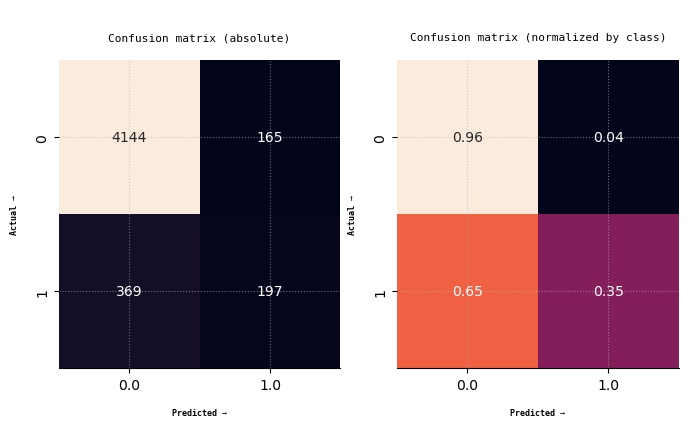

Accuracy: 0.89
Recall: 0.348
Precision: 0.544
F1: 0.425
ROC AUC: 0.655
**************************************** Men ************************************* 


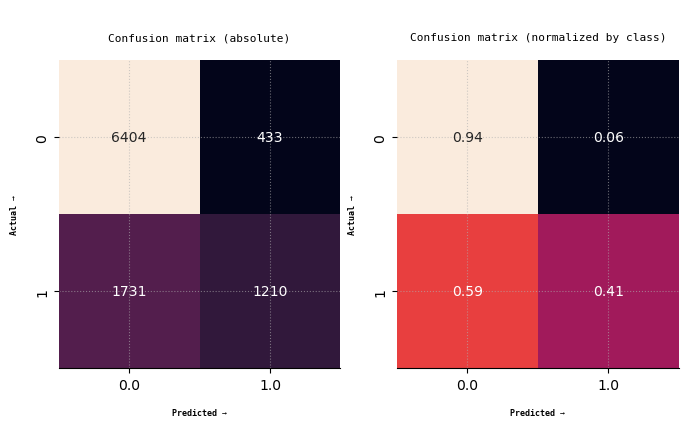

Accuracy: 0.779
Recall: 0.411
Precision: 0.736
F1: 0.528
ROC AUC: 0.674
**************************************** All ************************************* 


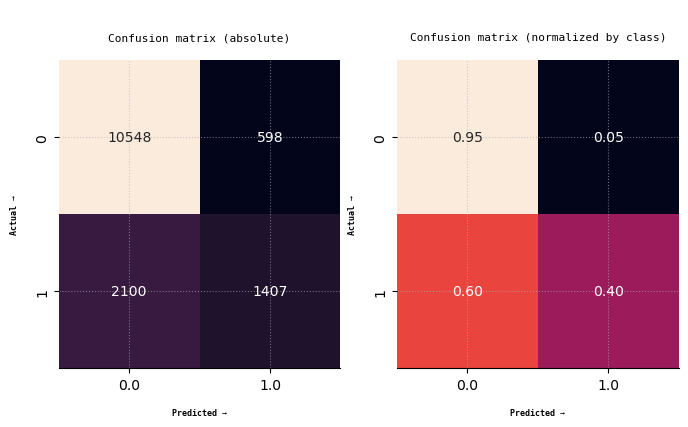

Accuracy: 0.816
Recall: 0.401
Precision: 0.702
F1: 0.511
ROC AUC: 0.674
Disparate impact: 0.442
Equal opportunity: 0.846


In [18]:
# Women
print('*************************************** Women ************************************ ')
print_performances(y_true=X_test1.loc[X_test1['gender'] == 'Female', 'income'].reset_index(drop=True),
                   y_hat=X_test_p1.loc[X_test_p1['gender'] == 'Female', 'prediction'].reset_index(drop=True))

# Men
print('**************************************** Men ************************************* ')
print_performances(y_true=X_test1.loc[X_test1['gender'] == 'Male', 'income'].reset_index(drop=True),
                   y_hat=X_test_p1.loc[X_test_p1['gender'] == 'Male', 'prediction'].reset_index(drop=True))

#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test1['income'], y_hat=X_test_p1['prediction'])

#Disparate impact:
PPF1 = (X_test_p1['prediction'][(X_test_p1['gender'] == 'Female') & (X_test_p1['prediction']==True)].count())
F1 = (X_test_p1['prediction'][(X_test_p1['gender'] == 'Female')]).count()
PPM1 = (X_test_p1['prediction'][(X_test_p1['gender'] == 'Male') & (X_test_p1['prediction']==True)].count())
M1 = (X_test_p1['prediction'][(X_test_p1['gender'] == 'Male')]).count()
DI1 = round((PPF1/F1)/(PPM1/M1), 3)

#Equal opportunity:
TPF1 = (X_test_p1['prediction'][(X_test_p1['gender'] == 'Female') & (X_test_p1['prediction']==True) & (X_test1['income']==True)].count())
APF1 = (X_test1['income'][(X_test1['gender'] == 'Female') & (X_test1['income']==True)].count())
TPM1 = (X_test_p1['prediction'][(X_test_p1['gender'] == 'Male') & (X_test_p1['prediction']==True) & (X_test1['income']==True)].count())
APM1 = (X_test1['income'][(X_test1['gender'] == 'Male') & (X_test1['income']==True)].count())
EQ1 = round((TPF1/APF1)/(TPM1/APM1), 3)

print(f'Disparate impact: {DI1}')
print (f'Equal opportunity: {EQ1}')

#### Za p=0.99

*************************************** Women ************************************ 


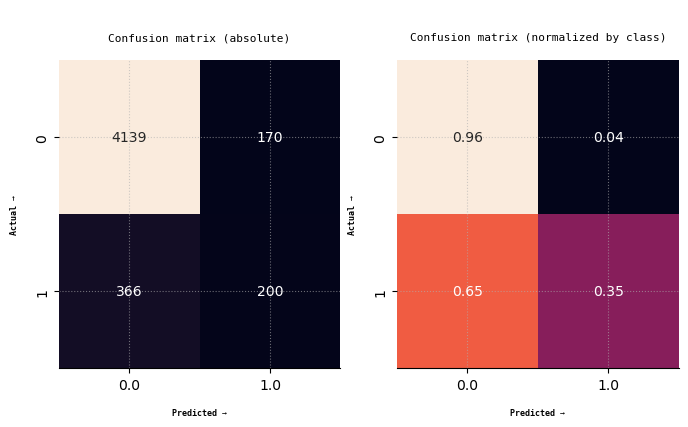

Accuracy: 0.89
Recall: 0.353
Precision: 0.541
F1: 0.427
ROC AUC: 0.657
**************************************** Men ************************************* 


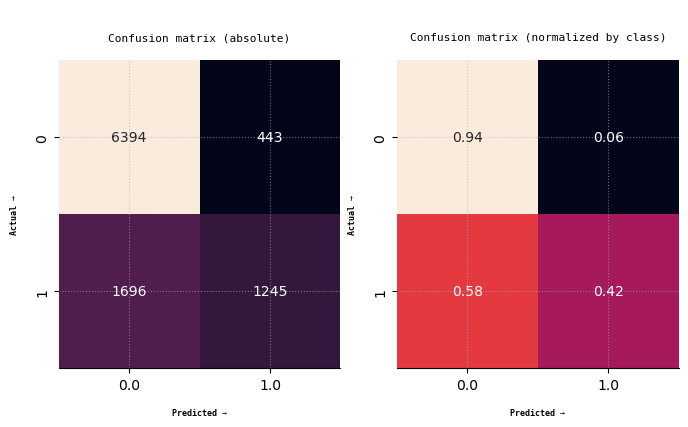

Accuracy: 0.781
Recall: 0.423
Precision: 0.738
F1: 0.538
ROC AUC: 0.679
**************************************** All ************************************* 


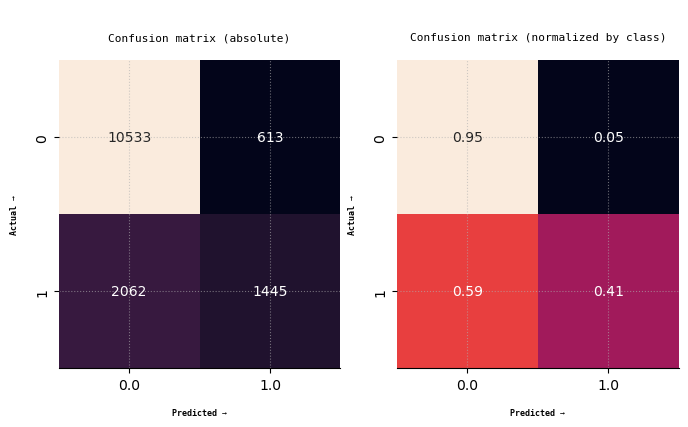

Accuracy: 0.817
Recall: 0.412
Precision: 0.702
F1: 0.519
ROC AUC: 0.679
Disparate impact: 0.44
Equal opportunity: 0.835


In [19]:
X_train2, X_test2 = train_test_split(data, test_size=0.3, random_state=297)
X_train2, X_test2 = X_train2.reset_index(drop=True), X_test2.reset_index(drop=True)

X_test_p2 = X_test2.drop('income', axis=1)

model2 = fit(data=X_train2, class_att='income', positive_class = 1, alpha=10, sensitive_att=['gender', 'relationship', 'race'], p=0.99)


for i in range(len(X_test_p2)):
    prediction2, confidence2 = predict(model2, X_test_p2.loc[i])
    
    X_test_p2.loc[i,'prediction'] = prediction2
    
    for klasa in confidence2:
        X_test_p2.loc[i,'class='+str(klasa)] = confidence2[klasa]

# Women
print('*************************************** Women ************************************ ')
print_performances(y_true=X_test2.loc[X_test2['gender'] == 'Female', 'income'].reset_index(drop=True),
                   y_hat=X_test_p2.loc[X_test_p2['gender'] == 'Female', 'prediction'].reset_index(drop=True))

# Men
print('**************************************** Men ************************************* ')
print_performances(y_true=X_test2.loc[X_test2['gender'] == 'Male', 'income'].reset_index(drop=True),
                   y_hat=X_test_p2.loc[X_test_p2['gender'] == 'Male', 'prediction'].reset_index(drop=True))

#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test2['income'], y_hat=X_test_p2['prediction'])

#Disparate impact:
PPF2 = (X_test_p2['prediction'][(X_test_p2['gender'] == 'Female') & (X_test_p2['prediction']==True)].count())
F2 = (X_test_p2['prediction'][(X_test_p2['gender'] == 'Female')]).count()
PPM2 = (X_test_p2['prediction'][(X_test_p2['gender'] == 'Male') & (X_test_p2['prediction']==True)].count())
M2 = (X_test_p2['prediction'][(X_test_p2['gender'] == 'Male')]).count()
DI2 = round((PPF2/F2)/(PPM2/M2), 3)

#Equal opportunity:
TPF2 = (X_test_p2['prediction'][(X_test_p2['gender'] == 'Female') & (X_test_p2['prediction']==True) & (X_test2['income']==True)].count())
APF2 = (X_test2['income'][(X_test2['gender'] == 'Female') & (X_test2['income']==True)].count())
TPM2 = (X_test_p2['prediction'][(X_test_p2['gender'] == 'Male') & (X_test_p2['prediction']==True) & (X_test2['income']==True)].count())
APM2 = (X_test2['income'][(X_test2['gender'] == 'Male') & (X_test2['income']==True)].count())
EQ2 = round((TPF2/APF2)/(TPM2/APM2), 3)


print(f'Disparate impact: {DI2}')
print (f'Equal opportunity: {EQ2}')

### Pomeranje granice odlučivanja

#### Threshold = 0,3

**************************************** All ************************************* 


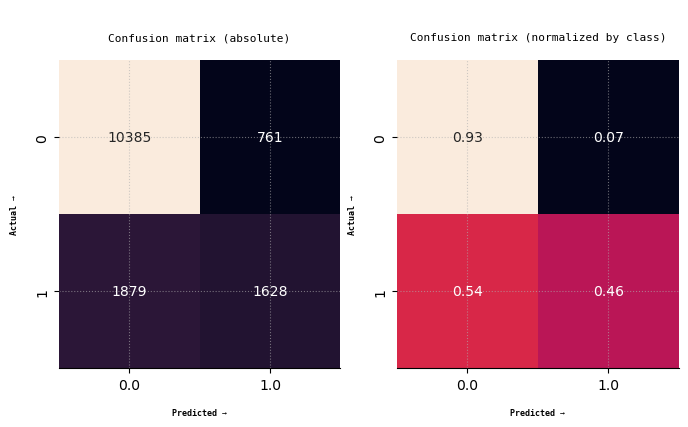

Accuracy: 0.82
Recall: 0.464
Precision: 0.681
F1: 0.552
ROC AUC: 0.698
Disparate impact: 0.424
Equal opportunity: 0.82


In [20]:
X_train3, X_test3 = train_test_split(data, test_size=0.3, random_state=297)
X_train3, X_test3 = X_train3.reset_index(drop=True), X_test3.reset_index(drop=True)

X_test_p3 = X_test3.drop('income', axis=1)

model3 = fit(data=X_train3, class_att='income', positive_class = 1, alpha=10, sensitive_att=['gender', 'relationship', 'race'], p=0.80)


for i in range(len(X_test_p3)):
    prediction3, confidence3 = predict(model=model3, new_instance=X_test_p3.loc[i], target_class=1, threshold=0.3)
    
    X_test_p3.loc[i,'prediction'] = prediction3
    
    for klasa in confidence3:
        X_test_p3.loc[i,'class='+str(klasa)] = confidence3[klasa]


#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test3['income'], y_hat=X_test_p3['prediction'])

#Disparate impact:
PPF3 = (X_test_p3['prediction'][(X_test_p3['gender'] == 'Female') & (X_test_p3['prediction']==True)].count())
F3 = (X_test_p3['prediction'][(X_test_p3['gender'] == 'Female')]).count()
PPM3 = (X_test_p3['prediction'][(X_test_p3['gender'] == 'Male') & (X_test_p3['prediction']==True)].count())
M3 = (X_test_p3['prediction'][(X_test_p3['gender'] == 'Male')]).count()
DI3 = round((PPF3/F3)/(PPM3/M3), 3)

#Equal opportunity:
TPF3 = (X_test_p3['prediction'][(X_test_p3['gender'] == 'Female') & (X_test_p3['prediction']==True) & (X_test3['income']==True)].count())
APF3 = (X_test3['income'][(X_test3['gender'] == 'Female') & (X_test3['income']==True)].count())
TPM3 = (X_test_p3['prediction'][(X_test_p3['gender'] == 'Male') & (X_test_p3['prediction']==True) & (X_test3['income']==True)].count())
APM3 = (X_test3['income'][(X_test3['gender'] == 'Male') & (X_test3['income']==True)].count())
EQ3 = round((TPF3/APF3)/(TPM3/APM3), 3)


print(f'Disparate impact: {DI3}')
print (f'Equal opportunity: {EQ3}')

#### Threshold = 0,4

**************************************** All ************************************* 


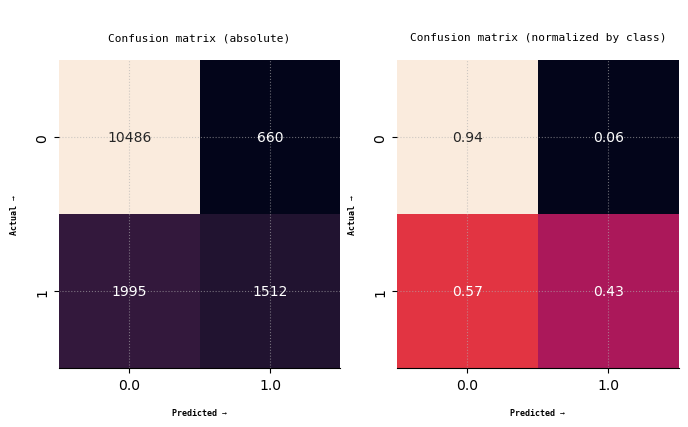

Accuracy: 0.819
Recall: 0.431
Precision: 0.696
F1: 0.532
ROC AUC: 0.686
Disparate impact: 0.429
Equal opportunity: 0.82


In [21]:
X_train4, X_test4 = train_test_split(data, test_size=0.3, random_state=297)
X_train4, X_test4 = X_train4.reset_index(drop=True), X_test4.reset_index(drop=True)

X_test_p4 = X_test4.drop('income', axis=1)

model4 = fit(data=X_train4, class_att='income', positive_class = 1, alpha=10, sensitive_att=['gender', 'relationship', 'race'], p=0.80)


for i in range(len(X_test_p4)):
    prediction4, confidence4 = predict(model=model4, new_instance=X_test_p4.loc[i], target_class=1, threshold=0.4)
    
    X_test_p4.loc[i,'prediction'] = prediction4
    
    for klasa in confidence4:
        X_test_p4.loc[i,'class='+str(klasa)] = confidence4[klasa]


#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test4['income'], y_hat=X_test_p4['prediction'])

#Disparate impact:
PPF4 = (X_test_p4['prediction'][(X_test_p4['gender'] == 'Female') & (X_test_p4['prediction']==True)].count())
F4 = (X_test_p4['prediction'][(X_test_p4['gender'] == 'Female')]).count()
PPM4 = (X_test_p4['prediction'][(X_test_p4['gender'] == 'Male') & (X_test_p4['prediction']==True)].count())
M4 = (X_test_p4['prediction'][(X_test_p4['gender'] == 'Male')]).count()
DI4 = round((PPF4/F4)/(PPM4/M4), 3)

#Equal opportunity:
TPF4 = (X_test_p4['prediction'][(X_test_p4['gender'] == 'Female') & (X_test_p4['prediction']==True) & (X_test4['income']==True)].count())
APF4 = (X_test4['income'][(X_test4['gender'] == 'Female') & (X_test4['income']==True)].count())
TPM4 = (X_test_p4['prediction'][(X_test_p4['gender'] == 'Male') & (X_test_p4['prediction']==True) & (X_test4['income']==True)].count())
APM4 = (X_test4['income'][(X_test4['gender'] == 'Male') & (X_test4['income']==True)].count())
EQ4 = round((TPF4/APF4)/(TPM4/APM4), 3)


print(f'Disparate impact: {DI4}')
print (f'Equal opportunity: {EQ4}')

#### Threshold = 0,6

**************************************** All ************************************* 


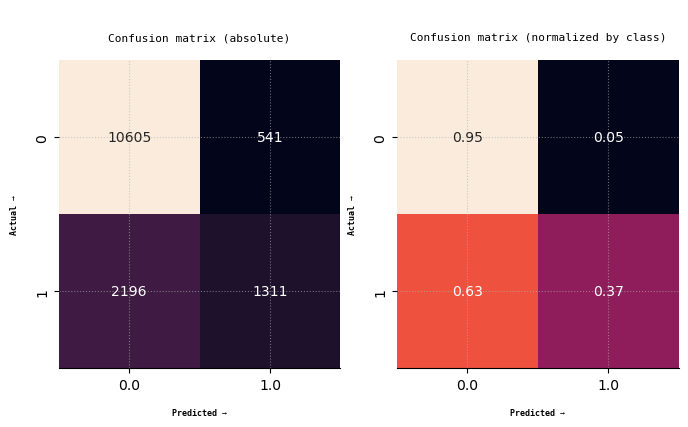

Accuracy: 0.813
Recall: 0.374
Precision: 0.708
F1: 0.489
ROC AUC: 0.663
Disparate impact: 0.448
Equal opportunity: 0.864


In [22]:
X_train5, X_test5 = train_test_split(data, test_size=0.3, random_state=297)
X_train5, X_test5 = X_train5.reset_index(drop=True), X_test5.reset_index(drop=True)

X_test_p5 = X_test5.drop('income', axis=1)

model5 = fit(data=X_train5, class_att='income', positive_class = 1, alpha=10, sensitive_att=['gender', 'relationship', 'race'], p=0.80)


for i in range(len(X_test_p5)):
    prediction5, confidence5 = predict(model=model5, new_instance=X_test_p5.loc[i], target_class=1, threshold=0.6)
    
    X_test_p5.loc[i,'prediction'] = prediction5
    
    for klasa in confidence5:
        X_test_p5.loc[i,'class='+str(klasa)] = confidence5[klasa]


#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test5['income'], y_hat=X_test_p5['prediction'])

#Disparate impact:
PPF5 = (X_test_p5['prediction'][(X_test_p5['gender'] == 'Female') & (X_test_p5['prediction']==True)].count())
F5 = (X_test_p5['prediction'][(X_test_p5['gender'] == 'Female')]).count()
PPM5 = (X_test_p5['prediction'][(X_test_p5['gender'] == 'Male') & (X_test_p5['prediction']==True)].count())
M5 = (X_test_p5['prediction'][(X_test_p5['gender'] == 'Male')]).count()
DI5 = round((PPF5/F5)/(PPM5/M5), 3)

#Equal opportunity:
TPF5 = (X_test_p5['prediction'][(X_test_p5['gender'] == 'Female') & (X_test_p5['prediction']==True) & (X_test5['income']==True)].count())
APF5 = (X_test5['income'][(X_test5['gender'] == 'Female') & (X_test5['income']==True)].count())
TPM5 = (X_test_p5['prediction'][(X_test_p5['gender'] == 'Male') & (X_test_p5['prediction']==True) & (X_test5['income']==True)].count())
APM5 = (X_test5['income'][(X_test5['gender'] == 'Male') & (X_test5['income']==True)].count())
EQ5 = round((TPF5/APF5)/(TPM5/APM5), 3)


print(f'Disparate impact: {DI5}')
print (f'Equal opportunity: {EQ5}')

#### Threshold = 0,7

**************************************** All ************************************* 


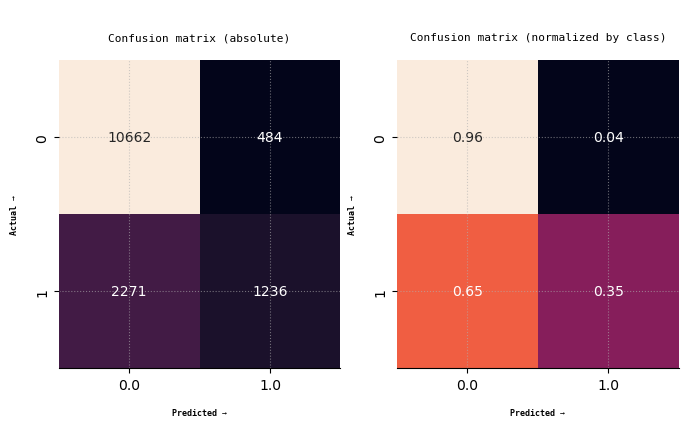

Accuracy: 0.812
Recall: 0.352
Precision: 0.719
F1: 0.473
ROC AUC: 0.655
Disparate impact: 0.462
Equal opportunity: 0.909


In [23]:
X_train6, X_test6 = train_test_split(data, test_size=0.3, random_state=297)
X_train6, X_test6 = X_train6.reset_index(drop=True), X_test6.reset_index(drop=True)

X_test_p6 = X_test6.drop('income', axis=1)

model6 = fit(data=X_train6, class_att='income', positive_class = 1, alpha=10, sensitive_att=['gender', 'relationship', 'race'], p=0.80)


for i in range(len(X_test_p6)):
    prediction6, confidence6 = predict(model=model6, new_instance=X_test_p6.loc[i], target_class=1, threshold=0.7)
    
    X_test_p6.loc[i,'prediction'] = prediction6
    
    for klasa in confidence6:
        X_test_p6.loc[i,'class='+str(klasa)] = confidence6[klasa]


#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test6['income'], y_hat=X_test_p6['prediction'])

#Disparate impact:
PPF6 = (X_test_p6['prediction'][(X_test_p6['gender'] == 'Female') & (X_test_p6['prediction']==True)].count())
F6 = (X_test_p6['prediction'][(X_test_p6['gender'] == 'Female')]).count()
PPM6 = (X_test_p6['prediction'][(X_test_p6['gender'] == 'Male') & (X_test_p6['prediction']==True)].count())
M6 = (X_test_p6['prediction'][(X_test_p6['gender'] == 'Male')]).count()
DI6 = round((PPF6/F6)/(PPM6/M6), 3)

#Equal opportunity:
TPF6 = (X_test_p6['prediction'][(X_test_p6['gender'] == 'Female') & (X_test_p6['prediction']==True) & (X_test6['income']==True)].count())
APF6 = (X_test6['income'][(X_test6['gender'] == 'Female') & (X_test6['income']==True)].count())
TPM6 = (X_test_p6['prediction'][(X_test_p6['gender'] == 'Male') & (X_test_p6['prediction']==True) & (X_test6['income']==True)].count())
APM6 = (X_test6['income'][(X_test6['gender'] == 'Male') & (X_test6['income']==True)].count())
EQ6 = round((TPF6/APF6)/(TPM6/APM6), 3)


print(f'Disparate impact: {DI6}')
print (f'Equal opportunity: {EQ6}')

#### Threshold = 0,8

*************************************** Women ************************************ 


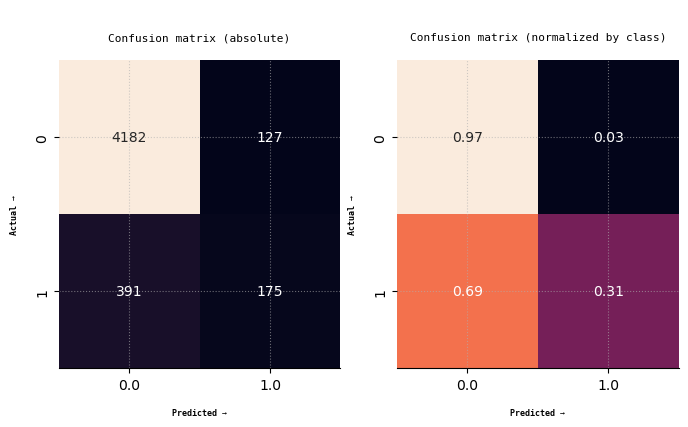

Accuracy: 0.894
Recall: 0.309
Precision: 0.579
F1: 0.403
ROC AUC: 0.64
**************************************** Men ************************************* 


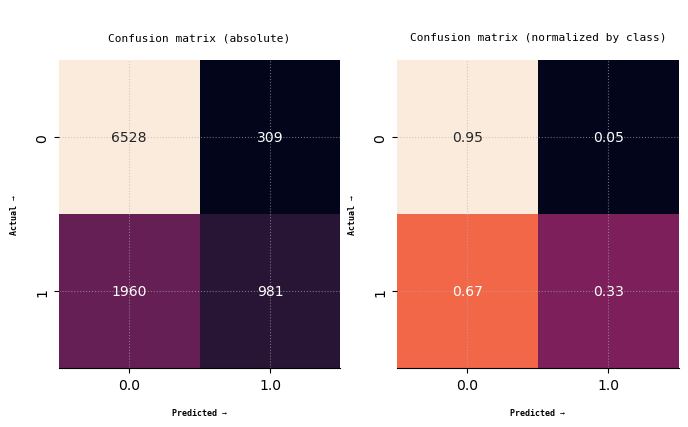

Accuracy: 0.768
Recall: 0.334
Precision: 0.76
F1: 0.464
ROC AUC: 0.644
**************************************** All ************************************* 


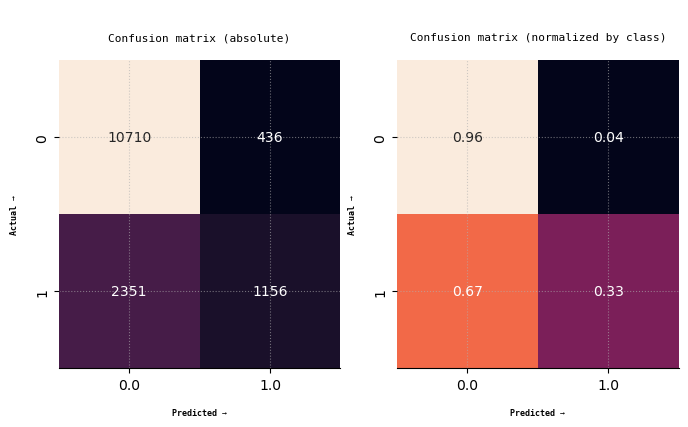

Accuracy: 0.81
Recall: 0.33
Precision: 0.726
F1: 0.453
ROC AUC: 0.645
Disparate impact: 0.47
Equal opportunity: 0.927


In [24]:
X_train7, X_test7 = train_test_split(data, test_size=0.3, random_state=297)
X_train7, X_test7 = X_train7.reset_index(drop=True), X_test7.reset_index(drop=True)

X_test_p7 = X_test7.drop('income', axis=1)

model7 = fit(data=X_train7, class_att='income', positive_class = 1, alpha=10, sensitive_att=['gender', 'relationship', 'race'], p=0.80)


for i in range(len(X_test_p7)):
    prediction7, confidence7 = predict(model=model7, new_instance=X_test_p7.loc[i], target_class=1, threshold=0.8)
    
    X_test_p7.loc[i,'prediction'] = prediction7
    
    for klasa in confidence7:
        X_test_p7.loc[i,'class='+str(klasa)] = confidence7[klasa]

# Women
print('*************************************** Women ************************************ ')
print_performances(y_true=X_test7.loc[X_test7['gender'] == 'Female', 'income'].reset_index(drop=True),
                   y_hat=X_test_p7.loc[X_test_p7['gender'] == 'Female', 'prediction'].reset_index(drop=True))

# Men
print('**************************************** Men ************************************* ')
print_performances(y_true=X_test7.loc[X_test7['gender'] == 'Male', 'income'].reset_index(drop=True),
                   y_hat=X_test_p7.loc[X_test_p7['gender'] == 'Male', 'prediction'].reset_index(drop=True))

#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test7['income'], y_hat=X_test_p7['prediction'])

#Disparate impact:
PPF7 = (X_test_p7['prediction'][(X_test_p7['gender'] == 'Female') & (X_test_p7['prediction']==True)].count())
F7 = (X_test_p7['prediction'][(X_test_p7['gender'] == 'Female')]).count()
PPM7 = (X_test_p7['prediction'][(X_test_p7['gender'] == 'Male') & (X_test_p7['prediction']==True)].count())
M7 = (X_test_p7['prediction'][(X_test_p7['gender'] == 'Male')]).count()
DI7 = round((PPF7/F7)/(PPM7/M7), 3)

#Equal opportunity:
TPF7 = (X_test_p7['prediction'][(X_test_p7['gender'] == 'Female') & (X_test_p7['prediction']==True) & (X_test7['income']==True)].count())
APF7 = (X_test7['income'][(X_test7['gender'] == 'Female') & (X_test7['income']==True)].count())
TPM7 = (X_test_p7['prediction'][(X_test_p7['gender'] == 'Male') & (X_test_p7['prediction']==True) & (X_test7['income']==True)].count())
APM7 = (X_test7['income'][(X_test7['gender'] == 'Male') & (X_test7['income']==True)].count())
EQ7 = round((TPF7/APF7)/(TPM7/APM7), 3)


print(f'Disparate impact: {DI7}')
print (f'Equal opportunity: {EQ7}')

# Optimizacija parametara

In [25]:
time_started = datetime.now()

X_train, X_test = train_test_split(data, test_size=0.3, random_state=297)
X_train, X_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True)
X_test_p = X_test.drop('income', axis=1)

p_params = np.linspace(start=0, stop=0.99, num=20)
p_params = np.round(p_params, 3)
t_params = np.linspace(start=0, stop=1, num=20)
t_params = np.round(t_params, 3)


DI=pd.DataFrame(data=None, index=p_params, columns=t_params)
EQ=pd.DataFrame(data=None, index=p_params, columns=t_params)
Acc=pd.DataFrame(data=None, index=p_params, columns=t_params)
Rec=pd.DataFrame(data=None, index=p_params, columns=t_params)
Prec=pd.DataFrame(data=None, index=p_params, columns=t_params)
F1=pd.DataFrame(data=None, index=p_params, columns=t_params)
AUC=pd.DataFrame(data=None, index=p_params, columns=t_params)



for pp in p_params:
    model = fit(data=X_train, class_att='income', positive_class = 1, alpha=10, sensitive_att=['gender', 'relationship', 'race'], p=pp)
    for t in t_params: 
        for i in range(len(X_test_p)):
            prediction, confidence = predict(model=model, new_instance=X_test_p.loc[i], target_class=1, other_class=0, threshold=t)
            X_test_p.loc[i,'prediction'] = prediction   
                
        DI.loc[pp, t] = di(X_test_p = X_test_p, prediction='prediction', sens_att='gender', priv_class='Male', disc_class='Female')
        EQ.loc[pp, t] = eq(X_test=X_test, X_test_p=X_test_p, actual='income', prediction='prediction', sens_att='gender', priv_class='Male', disc_class='Female')
        Acc.loc[pp, t] = round(accuracy_score(y_true=X_test['income'], y_pred=X_test_p['prediction']),3)
        Rec.loc[pp, t] = round(recall_score(y_true=X_test['income'], y_pred=X_test_p['prediction']), 3)
        Prec.loc[pp, t] = round(precision_score(y_true=X_test['income'], y_pred=X_test_p['prediction']), 3)
        F1.loc[pp, t] = round(f1_score(y_true=X_test['income'], y_pred=X_test_p['prediction']), 3)
        AUC.loc[pp, t] = round(roc_auc_score(y_true=X_test['income'], y_score=X_test_p['prediction']), 3)
                
        print(f'Završeno za: p={pp} i t={t}')
        
print(DI, EQ, Acc, Rec, Prec, F1, AUC)
time_finished = datetime.now()
run_last = (time_finished - time_started).seconds / 60
print(f'-----------------------------\nVreme izvršavanja: {run_last} mins.')

Atribut relationship je već više balansiran od traženih 0.0, zadržaće se postojeći balans koji iznosi 0.006454736162659351
Atribut race je već više balansiran od traženih 0.0, zadržaće se postojeći balans koji iznosi 0.005368406925244934
Atribut gender je već više balansiran od traženih 0.0, zadržaće se postojeći balans koji iznosi 0.17242367779848072
Završeno za: p=0.0 i t=0.0
Završeno za: p=0.0 i t=0.053
Završeno za: p=0.0 i t=0.105
Završeno za: p=0.0 i t=0.158
Završeno za: p=0.0 i t=0.211
Završeno za: p=0.0 i t=0.263
Završeno za: p=0.0 i t=0.316
Završeno za: p=0.0 i t=0.368
Završeno za: p=0.0 i t=0.421
Završeno za: p=0.0 i t=0.474
Završeno za: p=0.0 i t=0.526
Završeno za: p=0.0 i t=0.579
Završeno za: p=0.0 i t=0.632
Završeno za: p=0.0 i t=0.684
Završeno za: p=0.0 i t=0.737
Završeno za: p=0.0 i t=0.789
Završeno za: p=0.0 i t=0.842
Završeno za: p=0.0 i t=0.895
Završeno za: p=0.0 i t=0.947
Završeno za: p=0.0 i t=1.0
Atribut gender je već više balansiran od traženih 0.052, zadržaće se p

Završeno za: p=0.625 i t=0.263
Završeno za: p=0.625 i t=0.316
Završeno za: p=0.625 i t=0.368
Završeno za: p=0.625 i t=0.421
Završeno za: p=0.625 i t=0.474
Završeno za: p=0.625 i t=0.526
Završeno za: p=0.625 i t=0.579
Završeno za: p=0.625 i t=0.632
Završeno za: p=0.625 i t=0.684
Završeno za: p=0.625 i t=0.737
Završeno za: p=0.625 i t=0.789
Završeno za: p=0.625 i t=0.842
Završeno za: p=0.625 i t=0.895
Završeno za: p=0.625 i t=0.947
Završeno za: p=0.625 i t=1.0
Završeno za: p=0.677 i t=0.0
Završeno za: p=0.677 i t=0.053
Završeno za: p=0.677 i t=0.105
Završeno za: p=0.677 i t=0.158
Završeno za: p=0.677 i t=0.211
Završeno za: p=0.677 i t=0.263
Završeno za: p=0.677 i t=0.316
Završeno za: p=0.677 i t=0.368
Završeno za: p=0.677 i t=0.421
Završeno za: p=0.677 i t=0.474
Završeno za: p=0.677 i t=0.526
Završeno za: p=0.677 i t=0.579
Završeno za: p=0.677 i t=0.632
Završeno za: p=0.677 i t=0.684
Završeno za: p=0.677 i t=0.737
Završeno za: p=0.677 i t=0.789
Završeno za: p=0.677 i t=0.842
Završeno za:

In [26]:
DIc = DI.astype('float64')
EQc = EQ.astype('float64')

#### Različiti uticaj

In [27]:
DI

,0.000,0.053,0.105,0.158,0.211,0.263,0.316,0.368,0.421,0.474,0.526,0.579,0.632,0.684,0.737,0.789,0.842,0.895,0.947,1.000
0.000,1.0,0.483,0.461,0.449,0.439,0.435,0.428,0.432,0.431,0.438,0.446,0.454,0.454,0.462,0.464,0.464,0.477,0.49,0.481,0.571
0.052,1.0,0.381,0.38,0.376,0.381,0.378,0.385,0.39,0.394,0.393,0.401,0.399,0.406,0.412,0.424,0.429,0.435,0.443,0.461,0.55
0.104,1.0,0.403,0.391,0.393,0.392,0.392,0.398,0.396,0.398,0.41,0.413,0.412,0.42,0.429,0.433,0.435,0.449,0.453,0.466,0.55
0.156,1.0,0.413,0.406,0.403,0.401,0.406,0.408,0.403,0.41,0.416,0.415,0.419,0.428,0.434,0.437,0.448,0.448,0.458,0.466,0.557
0.208,1.0,0.323,0.327,0.327,0.33,0.329,0.329,0.333,0.338,0.345,0.351,0.36,0.372,0.376,0.377,0.397,0.413,0.432,0.444,0.542
0.261,1.0,0.346,0.345,0.344,0.343,0.347,0.344,0.348,0.349,0.361,0.369,0.375,0.387,0.397,0.395,0.408,0.425,0.442,0.446,0.542
0.313,1.0,0.362,0.364,0.358,0.354,0.36,0.36,0.36,0.368,0.372,0.381,0.384,0.403,0.406,0.405,0.418,0.432,0.448,0.45,0.55
0.365,1.0,0.376,0.378,0.377,0.366,0.369,0.368,0.373,0.382,0.386,0.39,0.395,0.414,0.419,0.424,0.428,0.439,0.454,0.454,0.55
0.417,1.0,0.391,0.388,0.386,0.376,0.378,0.378,0.389,0.389,0.396,0.397,0.408,0.42,0.427,0.431,0.434,0.45,0.461,0.463,0.557
0.469,1.0,0.404,0.4,0.394,0.384,0.389,0.388,0.399,0.403,0.403,0.407,0.415,0.429,0.434,0.443,0.442,0.453,0.465,0.469,0.557


<AxesSubplot:>

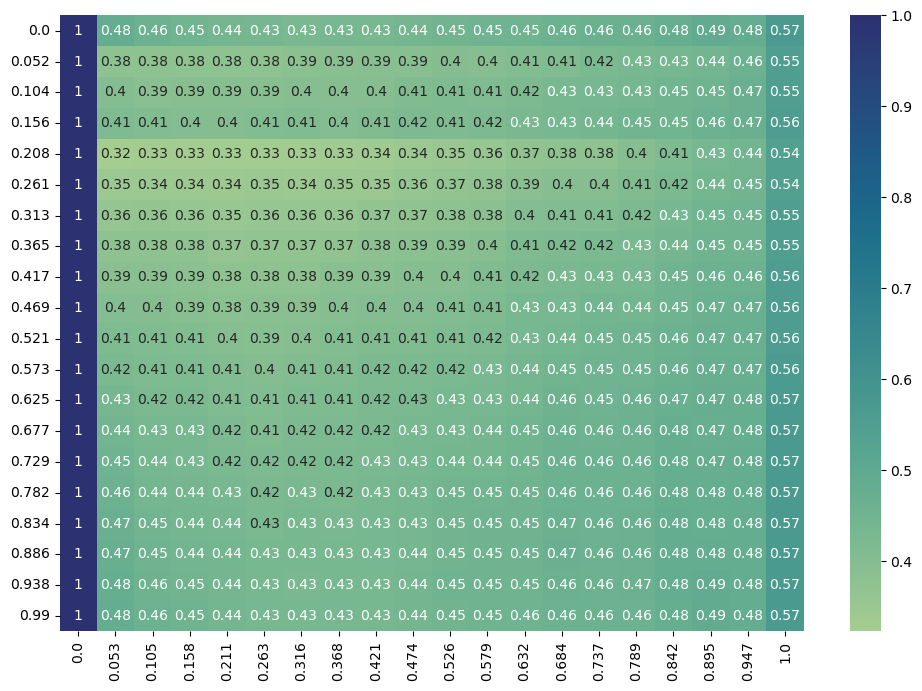

In [28]:
plt.subplots(figsize=(12, 8))
sns.heatmap(data=DIc, annot=True, cmap="crest")

#### Jednake šanse

In [29]:
EQ

,0.000,0.053,0.105,0.158,0.211,0.263,0.316,0.368,0.421,0.474,0.526,0.579,0.632,0.684,0.737,0.789,0.842,0.895,0.947,1.000
0.000,1.0,0.898,0.895,0.857,0.833,0.815,0.815,0.825,0.814,0.833,0.849,0.87,0.875,0.895,0.909,0.921,0.945,0.976,0.998,1.474
0.052,1.0,0.842,0.804,0.809,0.821,0.813,0.811,0.815,0.808,0.805,0.828,0.82,0.826,0.849,0.873,0.874,0.9,0.921,0.966,1.417
0.104,1.0,0.862,0.81,0.815,0.827,0.825,0.827,0.806,0.813,0.84,0.836,0.826,0.841,0.878,0.871,0.881,0.92,0.929,0.974,1.417
0.156,1.0,0.865,0.831,0.825,0.83,0.835,0.827,0.813,0.839,0.839,0.828,0.842,0.856,0.871,0.874,0.904,0.929,0.942,0.976,1.436
0.208,1.0,0.713,0.702,0.698,0.696,0.685,0.682,0.692,0.7,0.715,0.718,0.738,0.765,0.787,0.793,0.827,0.869,0.918,0.974,1.398
0.261,1.0,0.745,0.726,0.718,0.717,0.712,0.705,0.709,0.725,0.743,0.749,0.758,0.786,0.818,0.816,0.848,0.891,0.93,0.976,1.398
0.313,1.0,0.757,0.751,0.742,0.728,0.735,0.718,0.728,0.751,0.757,0.767,0.769,0.814,0.83,0.835,0.864,0.9,0.945,0.979,1.417
0.365,1.0,0.776,0.769,0.76,0.747,0.747,0.727,0.748,0.765,0.778,0.782,0.789,0.831,0.844,0.856,0.879,0.913,0.95,0.984,1.417
0.417,1.0,0.795,0.788,0.769,0.758,0.757,0.745,0.776,0.775,0.792,0.791,0.809,0.84,0.857,0.871,0.89,0.928,0.962,0.985,1.436
0.469,1.0,0.818,0.8,0.789,0.772,0.763,0.77,0.784,0.79,0.801,0.806,0.82,0.852,0.865,0.882,0.894,0.935,0.965,0.987,1.436


<AxesSubplot:>

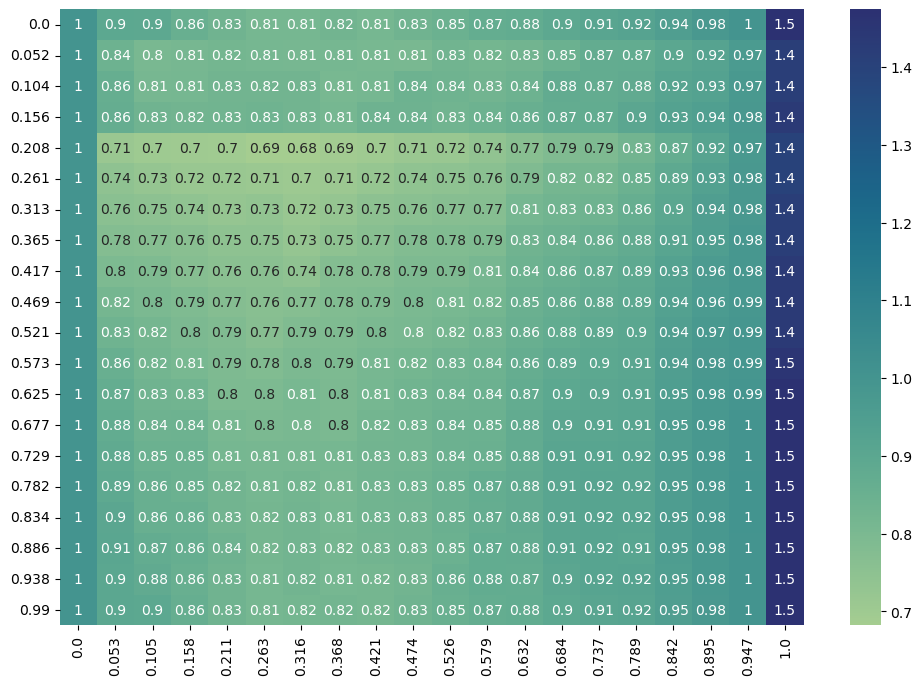

In [30]:
plt.subplots(figsize=(12,8))
sns.heatmap(data=EQc, annot=True, cmap="crest")

#### Mere tačnosti

In [31]:
Accc = Acc.astype('float64')
Recc = Rec.astype('float64')
Precc = Prec.astype('float')
F1c = F1.astype('float64')
AUCc = AUC.astype('float64')

Accuracy:


<AxesSubplot:>

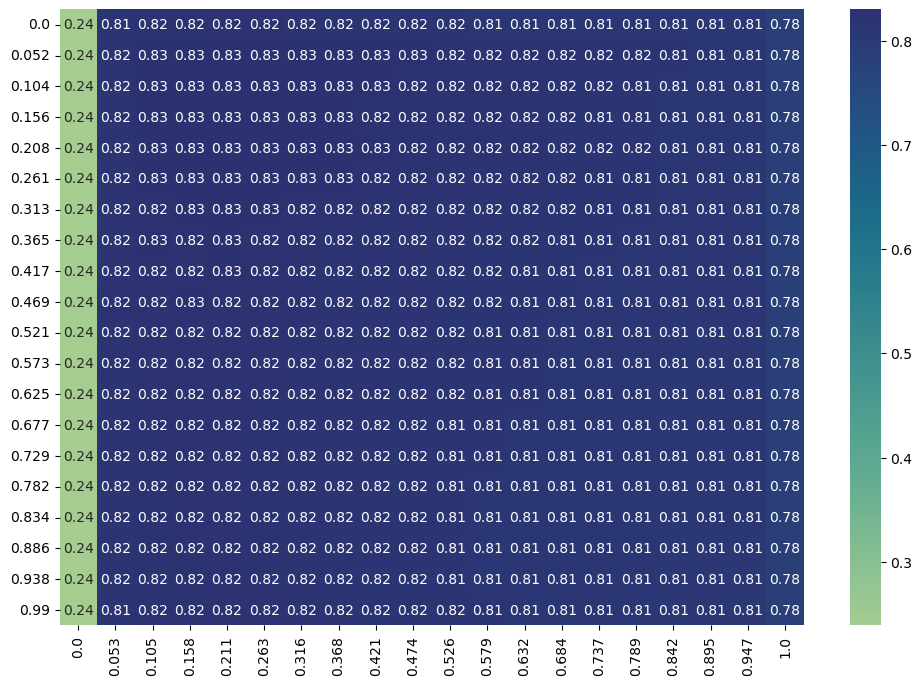

In [32]:
print('Accuracy:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=Accc, annot=True, cmap="crest")

Recall:


<AxesSubplot:>

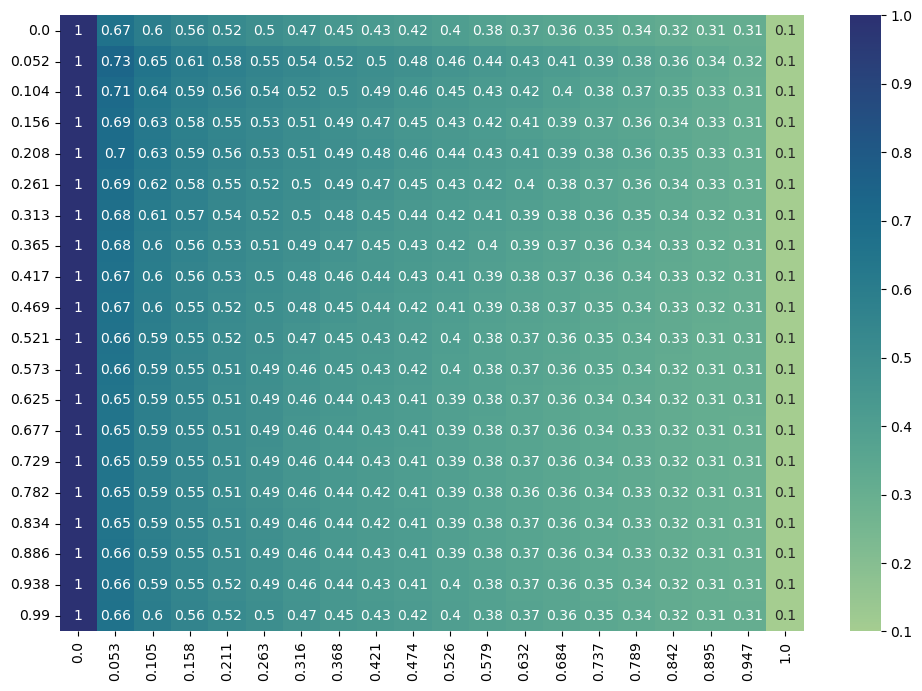

In [33]:
print('Recall:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=Recc, annot=True, cmap="crest")

Precision:


<AxesSubplot:>

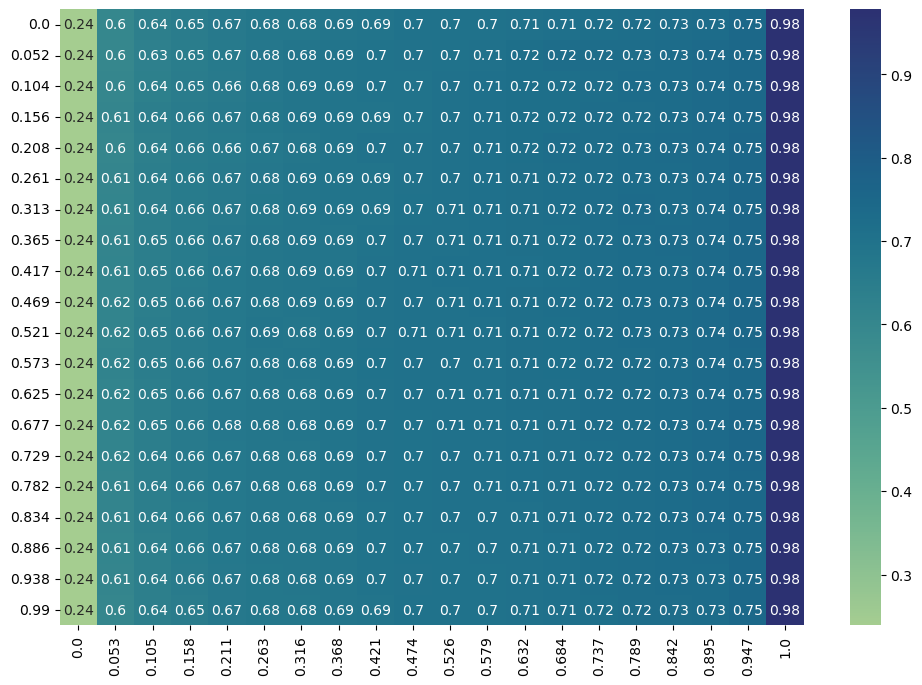

In [34]:
print('Precision:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=Precc, annot=True, cmap="crest")

F1:


<AxesSubplot:>

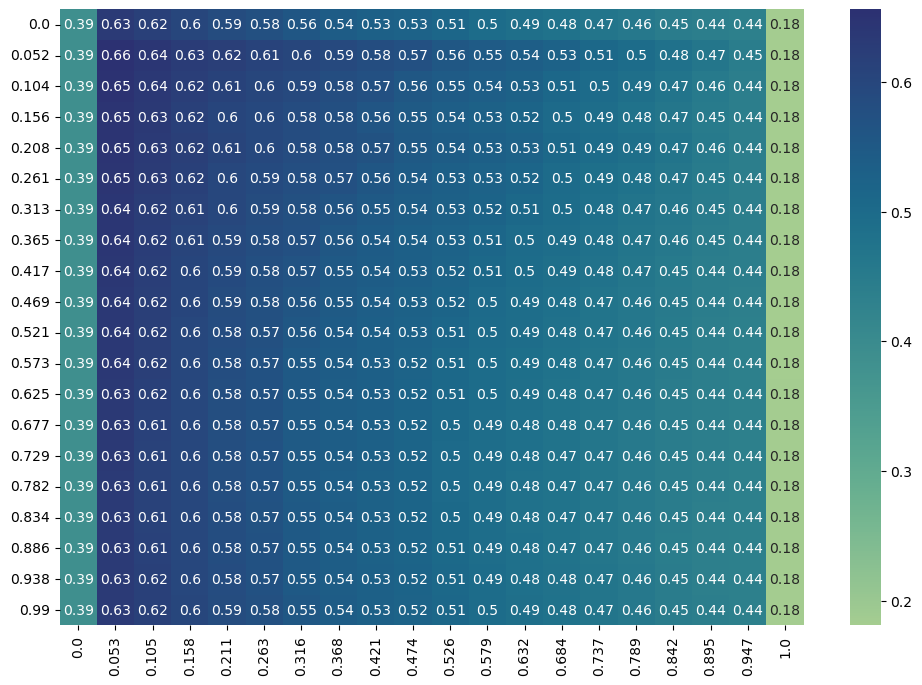

In [35]:
print('F1:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=F1c, annot=True, cmap="crest")

AUC:


<AxesSubplot:>

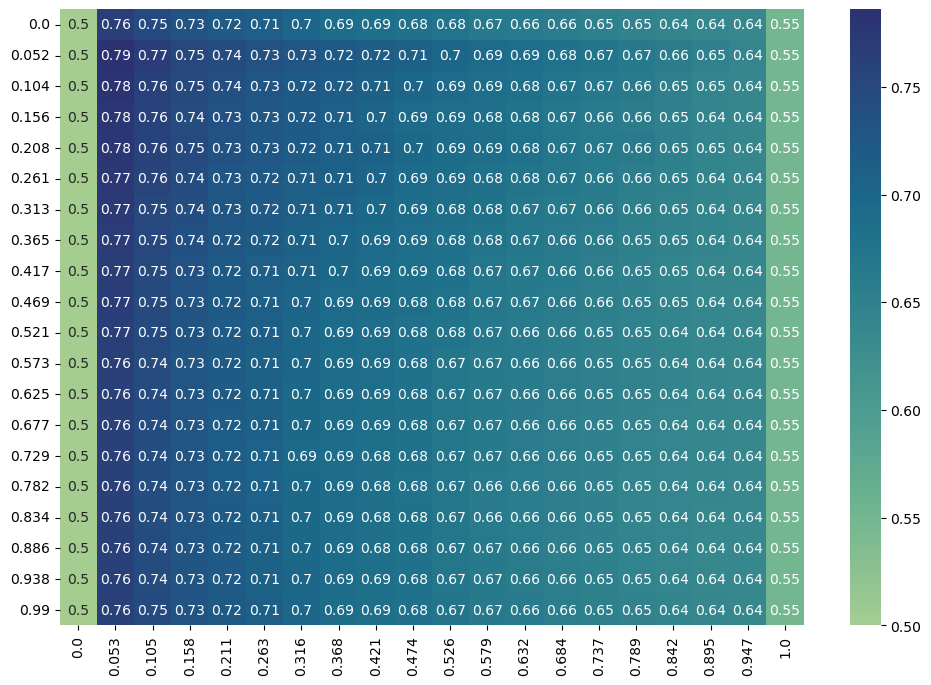

In [36]:
print('AUC:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=AUCc, annot=True, cmap="crest")

Poredjenjem vrednosti mera diskriminacije uočavamo da se najbolji rezultati postižu u ekstremnim vrednostima parametara. Medjutim, vrednosti mera tačnosti, pri takvim vrednostima parametara, se drastično smanjuju. Ovo je bilo očekivano, znajući da postoji odredjen inverzan odnos ovih mera, zbog činjenice da je u podacima sadržana istorijska diskriminacija. U nastavku ćemo prikazati jesnije odnos izmedju mera tačnosti i mera diskriminacije, kao i uticaj pomeranja granice odlučivanja. Za referentne vrednosti ćemo koristiti vrednosti parametra za bilans od 0.834, 0.886, 0.938 i 0.99, ove vrednosti uzimamo jer je Komisija za jednake šanse zapošljavanja u SAD-u, propisala vrednosti preko 0.80 dozvoljenim odnosom izmedju grupa.

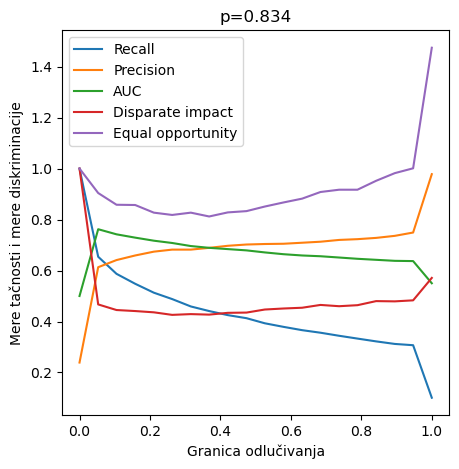

In [37]:
plt.rcParams['figure.figsize']=[5,5]
plt.plot(Recc.loc[0.834,:])
plt.plot(Precc.loc[0.834,:])
plt.plot(AUCc.loc[0.834,:])
plt.plot(DIc.loc[0.834,:])
plt.plot(EQc.loc[0.834,:])
plt.legend(['Recall', 'Precision', 'AUC', 'Disparate impact', 'Equal opportunity'])
plt.xlabel("Granica odlučivanja")
plt.ylabel("Mere tačnosti i mere diskriminacije")
plt.title('p=0.834')
plt.show()

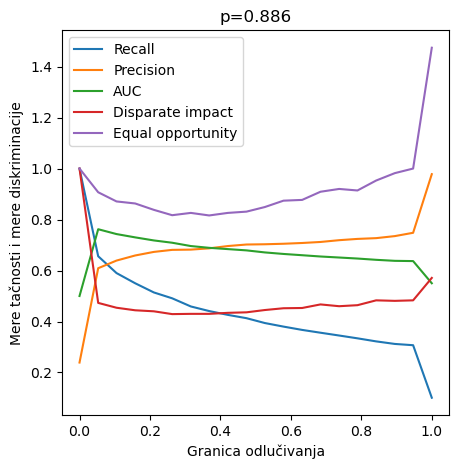

In [38]:
plt.rcParams['figure.figsize']=[5,5]
plt.plot(Recc.loc[0.886,:])
plt.plot(Precc.loc[0.886,:])
plt.plot(AUCc.loc[0.886,:])
plt.plot(DIc.loc[0.886,:])
plt.plot(EQc.loc[0.886,:])
plt.legend(['Recall', 'Precision', 'AUC', 'Disparate impact', 'Equal opportunity'])
plt.xlabel("Granica odlučivanja")
plt.ylabel("Mere tačnosti i mere diskriminacije")
plt.title('p=0.886')
plt.show()

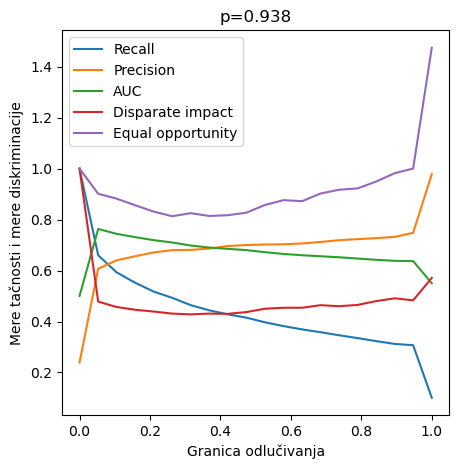

In [39]:
plt.rcParams['figure.figsize']=[5,5]
plt.plot(Recc.loc[0.938,:])
plt.plot(Precc.loc[0.938,:])
plt.plot(AUCc.loc[0.938,:])
plt.plot(DIc.loc[0.938,:])
plt.plot(EQc.loc[0.938,:])
plt.legend(['Recall', 'Precision', 'AUC', 'Disparate impact', 'Equal opportunity'])
plt.xlabel("Granica odlučivanja")
plt.ylabel("Mere tačnosti i mere diskriminacije")
plt.title('p=0.938')
plt.show()

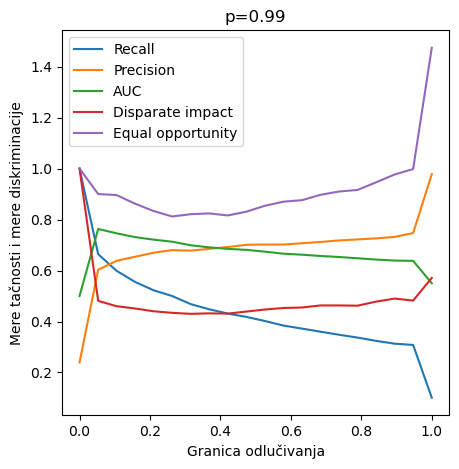

In [40]:
plt.rcParams['figure.figsize']=[5,5]
plt.plot(Recc.loc[0.99,:])
plt.plot(Precc.loc[0.99,:])
plt.plot(AUCc.loc[0.99,:])
plt.plot(DIc.loc[0.99,:])
plt.plot(EQc.loc[0.99,:])
plt.legend(['Recall', 'Precision', 'AUC', 'Disparate impact', 'Equal opportunity'])
plt.xlabel("Granica odlučivanja")
plt.ylabel("Mere tačnosti i mere diskriminacije")
plt.title('p=0.99')
plt.show()

Možemo uočiti da, po obe mere, savršenu pravednost postižemo pri granici odlučivanja od 0, odnosno ako bismo sve proglasili za pozitivnu klasu.  Medjutim, osim što vrednosti parametara tačnosti (osim recall) nisu zadovoljavajuće, u praksi nema smisla ovaj postupak. Takodje, uocavamo da nema puno razlike u odnosu na to koju vrednost p, od izabrane četiri vrednosti, koristimo. U nastavku ćemo da analiziramo rezultate koji se postižu sa vrednostima granice odlučivanja od 0.053, 0.105, 0.895 i 0.947.

#### p = 0.834

In [41]:
rez1 = [[Accc.loc[0.834, 0.053], Recc.loc[0.834, 0.053], Precc.loc[0.834, 0.053], F1c.loc[0.834, 0.053], AUCc.loc[0.834, 0.053], DIc.loc[0.834, 0.053], EQc.loc[0.834, 0.053]],
        [Accc.loc[0.834, 0.105], Recc.loc[0.834, 0.105], Precc.loc[0.834, 0.105], F1c.loc[0.834, 0.105], AUCc.loc[0.834, 0.105], DIc.loc[0.834, 0.105], EQc.loc[0.834, 0.105]],
        [Accc.loc[0.834, 0.895], Recc.loc[0.834, 0.895], Precc.loc[0.834, 0.895], F1c.loc[0.834, 0.895], AUCc.loc[0.834, 0.895], DIc.loc[0.834, 0.895], EQc.loc[0.834, 0.895]],
        [Accc.loc[0.834, 0.947], Recc.loc[0.834, 0.947], Precc.loc[0.834, 0.947], F1c.loc[0.834, 0.947], AUCc.loc[0.834, 0.947], DIc.loc[0.834, 0.947], EQc.loc[0.834, 0.947]]]

rezultati1 = pd.DataFrame(rez1, columns=('Accuracy', 'Recall', 'Precision', 'F1', 'AUC', 
                                         'Disparate impact', 'Equal opportunity'), index=(0.053, 0.105, 0.895, 0.947))
rezultati1

,Accuracy,Recall,Precision,F1,AUC,Disparate impact,Equal opportunity
0.053,0.818,0.654,0.613,0.633,0.762,0.467,0.904
0.105,0.823,0.587,0.641,0.613,0.742,0.445,0.858
0.895,0.809,0.312,0.736,0.438,0.638,0.479,0.982
0.947,0.810,0.307,0.749,0.436,0.637,0.483,1.001


#### p = 0.886 

In [42]:
rez2 = [[Accc.loc[0.886, 0.053], Recc.loc[0.886, 0.053], Precc.loc[0.886, 0.053], F1c.loc[0.886, 0.053], AUCc.loc[0.886, 0.053], DIc.loc[0.886, 0.053], EQc.loc[0.886, 0.053]],
        [Accc.loc[0.886, 0.105], Recc.loc[0.886, 0.105], Precc.loc[0.886, 0.105], F1c.loc[0.886, 0.105], AUCc.loc[0.886, 0.105], DIc.loc[0.886, 0.105], EQc.loc[0.886, 0.105]],
        [Accc.loc[0.886, 0.895], Recc.loc[0.886, 0.895], Precc.loc[0.886, 0.895], F1c.loc[0.886, 0.895], AUCc.loc[0.886, 0.895], DIc.loc[0.886, 0.895], EQc.loc[0.886, 0.895]],
        [Accc.loc[0.886, 0.947], Recc.loc[0.886, 0.947], Precc.loc[0.886, 0.947], F1c.loc[0.886, 0.947], AUCc.loc[0.886, 0.947], DIc.loc[0.886, 0.947], EQc.loc[0.886, 0.947]]]

rezultati2 = pd.DataFrame(rez2, columns=('Accuracy', 'Recall', 'Precision', 'F1', 'AUC', 
                                         'Disparate impact', 'Equal opportunity'), index=(0.053, 0.105, 0.895, 0.947))
rezultati2

,Accuracy,Recall,Precision,F1,AUC,Disparate impact,Equal opportunity
0.053,0.817,0.656,0.609,0.632,0.762,0.473,0.907
0.105,0.822,0.590,0.639,0.614,0.743,0.454,0.871
0.895,0.809,0.312,0.735,0.438,0.638,0.481,0.982
0.947,0.809,0.307,0.748,0.436,0.637,0.483,1.000


#### p = 0.938

In [43]:
rez3 = [[Accc.loc[0.938, 0.053], Recc.loc[0.938, 0.053], Precc.loc[0.938, 0.053], F1c.loc[0.938, 0.053], AUCc.loc[0.938, 0.053], DIc.loc[0.938, 0.053], EQc.loc[0.938, 0.053]],
        [Accc.loc[0.938, 0.105], Recc.loc[0.938, 0.105], Precc.loc[0.938, 0.105], F1c.loc[0.938, 0.105], AUCc.loc[0.938, 0.105], DIc.loc[0.938, 0.105], EQc.loc[0.938, 0.105]],
        [Accc.loc[0.938, 0.895], Recc.loc[0.938, 0.895], Precc.loc[0.938, 0.895], F1c.loc[0.938, 0.895], AUCc.loc[0.938, 0.895], DIc.loc[0.938, 0.895], EQc.loc[0.938, 0.895]],
        [Accc.loc[0.938, 0.947], Recc.loc[0.938, 0.947], Precc.loc[0.938, 0.947], F1c.loc[0.938, 0.947], AUCc.loc[0.938, 0.947], DIc.loc[0.938, 0.947], EQc.loc[0.938, 0.947]]]

rezultati3 = pd.DataFrame(rez3, columns=('Accuracy', 'Recall', 'Precision', 'F1', 'AUC', 
                                         'Disparate impact', 'Equal opportunity'), index=(0.053, 0.105, 0.895, 0.947))
rezultati3

,Accuracy,Recall,Precision,F1,AUC,Disparate impact,Equal opportunity
0.053,0.816,0.660,0.607,0.632,0.763,0.478,0.901
0.105,0.823,0.593,0.640,0.616,0.744,0.457,0.882
0.895,0.808,0.312,0.732,0.438,0.638,0.491,0.982
0.947,0.809,0.307,0.748,0.436,0.637,0.483,1.000


#### p = 0.99

In [44]:
rez4 = [[Accc.loc[0.99, 0.053], Recc.loc[0.99, 0.053], Precc.loc[0.99, 0.053], F1c.loc[0.99, 0.053], AUCc.loc[0.99, 0.053], DIc.loc[0.99, 0.053], EQc.loc[0.99, 0.053]],
        [Accc.loc[0.99, 0.105], Recc.loc[0.99, 0.105], Precc.loc[0.99, 0.105], F1c.loc[0.99, 0.105], AUCc.loc[0.99, 0.105], DIc.loc[0.99, 0.105], EQc.loc[0.99, 0.105]],
        [Accc.loc[0.99, 0.895], Recc.loc[0.99, 0.895], Precc.loc[0.99, 0.895], F1c.loc[0.99, 0.895], AUCc.loc[0.99, 0.895], DIc.loc[0.99, 0.895], EQc.loc[0.99, 0.895]],
        [Accc.loc[0.99, 0.947], Recc.loc[0.99, 0.947], Precc.loc[0.99, 0.947], F1c.loc[0.99, 0.947], AUCc.loc[0.99, 0.947], DIc.loc[0.99, 0.947], EQc.loc[0.99, 0.947]]]

rezultati4 = pd.DataFrame(rez4, columns=('Accuracy', 'Recall', 'Precision', 'F1', 'AUC', 
                                         'Disparate impact', 'Equal opportunity'), index=(0.053, 0.105, 0.895, 0.947))
rezultati4

,Accuracy,Recall,Precision,F1,AUC,Disparate impact,Equal opportunity
0.053,0.815,0.664,0.603,0.632,0.763,0.481,0.900
0.105,0.823,0.599,0.638,0.618,0.746,0.460,0.896
0.895,0.808,0.313,0.732,0.439,0.639,0.490,0.977
0.947,0.809,0.308,0.747,0.436,0.638,0.482,0.998


Najbolje su se pokazali, po pitanju smanjenja diskriminacije, modeli sa p=0.886 i p=0.938 pri granicama odlučivanja od 0.895 i 0.947.